In [3]:
!pip install -qr requirements.txt

In [4]:
%load_ext autoreload
%autoreload 2

In [5]:
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import os
import json 


# deep stuff
import torch
from torch_geometric.utils import from_networkx

In [6]:
from src.community_results import community_metrics, plot_communities, community_size_hist
from src.clustering import label_propagation, louvain, leiden, kmeans, optics
from src.DGIModel import DGIModel
from src.GAT import  GAT, contrastive_loss
from src.tune import tune, tune_variance_contrastive

/home/jann/GAT/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Load dataset

In [7]:
data_path = './data/deezer_clean_data/'

edges = os.path.join(data_path, 'HR_edges.csv')
genres = os.path.join(data_path, 'HR_genres.json')

In [8]:
edges_df = pd.read_csv(edges)
g = nx.from_pandas_edgelist(edges_df, source='node_1', target='node_2')

In [9]:
with open(genres, 'r') as f:
    genres_data = json.load(f)


In [10]:
def encode_genres(genre_list, unique_genres):
    encoding = [1 if genre in genre_list else 0 for genre in unique_genres]
    return encoding


def decode_genres(genre_vector, unique_genres):
    decoded_genres = [unique_genres[i] for i in range(len(genre_vector)) if genre_vector[i] == 1]
    return decoded_genres

In [11]:
all_genres = set()
for genres in genres_data.values():
    all_genres.update(genres)

all_genres = sorted(all_genres)

for user_id, genres in genres_data.items():
    if isinstance(user_id, str):
        user_id = int(user_id)
    if user_id in g.nodes:
        g.nodes[user_id]['genres'] = encode_genres(genres, all_genres)

In [12]:
sel_graph = 'deezer'
# nx.draw(g, with_labels=True)

In [ ]:
best_results = dict()

# Apply graph based clustering

## Label Propagation

In [13]:
lp_trials = []

In [14]:
# based on results in paper, experiments with higher value 
# confirm authors' statement that modularity doesn't change much
for i in (1, 5, 15):
    start = time.time()
    lp_labels = label_propagation(g, aggr_runs=i)

    # Calculate metrics for LP
    lp_metrics = community_metrics(g, lp_labels)
    lp_trials.append({**lp_metrics, 'elapsed_time': time.time() - start, 'Iterations': i})

lp_df = pd.DataFrame(lp_trials)
best_results['Label Propagation'] = lp_df.loc[lp_df['Modularity'].idxmax()]
best_results['Label Propagation']

Number of Communities             308.000000
Average Community Size            177.185065
Modularity                          0.691047
Average Cluster Coefficients        0.136477
Number of connected components      1.000000
Coverage                            0.756448
Performance                         0.909750
Iterations                          5.000000
Name: 1, dtype: float64

## Louvain

In [ ]:
lv_trials = []

In [10]:
for i in (0.1, 0.5, 1.0, 1.5):
    start = time.time()
    lv_labels = louvain(g, resolution=i)

    # Calculate metrics for Louvain
    lv_metrics = community_metrics(g, lv_labels)
    lv_trials.append({**lv_metrics, 'elapsed_time': time.time() - start, 'Resolution': i})

lv_df = pd.DataFrame(lv_trials)
best_results['Louvaine'] = lv_df.loc[lv_df['Modularity'].idxmax()]
best_results['Louvaine']

{'Number of Communities': 24,
 'Average Community Size': 2273.875,
 'Modularity': 0.7392975648922048,
 'Coverage': 0.8074275093235274,
 'Performance': 0.9270869907537564}

## Leiden

In [ ]:
ld_trials = []

In [11]:
for i in (0.01, 0.05, 0.1, 0.5, 1.0, 2):
    start = time.time()
    ld_labels = leiden(g, resolution=i)

    # Calculate metrics for Leiden
    ld_metrics = community_metrics(g, ld_labels)
    ld_trials.append({**ld_metrics, 'elapsed_time': time.time() - start, 'Resolution': i})


ld_df = pd.DataFrame(ld_trials)
best_results['Leiden'] = ld_df.loc[ld_df['Modularity'].idxmax()]
best_results['Leiden']

{'Number of Communities': 24,
 'Average Community Size': 2273.875,
 'Modularity': 0.7421684545988803,
 'Coverage': 0.8090995218806829,
 'Performance': 0.928518812822755}

# Apply GAT Embedding

We will try to train GAT using 3 different loss function and compare the obtained results. The loss functions are:
1. DGI (Deep Graph Infomax)
2. Embedding variance
3. Contrastive loss between connected and unconnected nodes


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

In [ ]:
# Convert networkx graph to PyTorch Geometric data object
data = from_networkx(g)

# Since the graph doesn't have node features, we use an identity matrix
data.x = torch.tensor([g.nodes[n]['genres'] for n in g.nodes], dtype=torch.float)

## DGI loss

### Hyperparameter selection

In [ ]:
# Select best hyperparameters
best_parameters_optuna_dgi = tune(data)

[I 2024-08-14 00:26:37,318] A new study created in memory with name: no-name-6dd697fb-e242-46e8-b7d4-e771a409ff6b
Best trial: 15. Best value: 0.528: 100%|██████████| 50/50 [02:12<00:00,  2.65s/it]  


### Model evaluation

In [ ]:
gat_dgi_communities = best_parameters_optuna_dgi.best_trial.user_attrs['communities']
best_method = best_parameters_optuna_dgi.best_trial.user_attrs['best_method']
best_results['GAT + DGI loss'] = best_parameters_optuna_dgi.best_trial.user_attrs['metrics']
best_results['GAT + DGI loss']['elapsed_time'] = best_parameters_optuna_dgi.best_trial.user_attrs['elapsed_time']

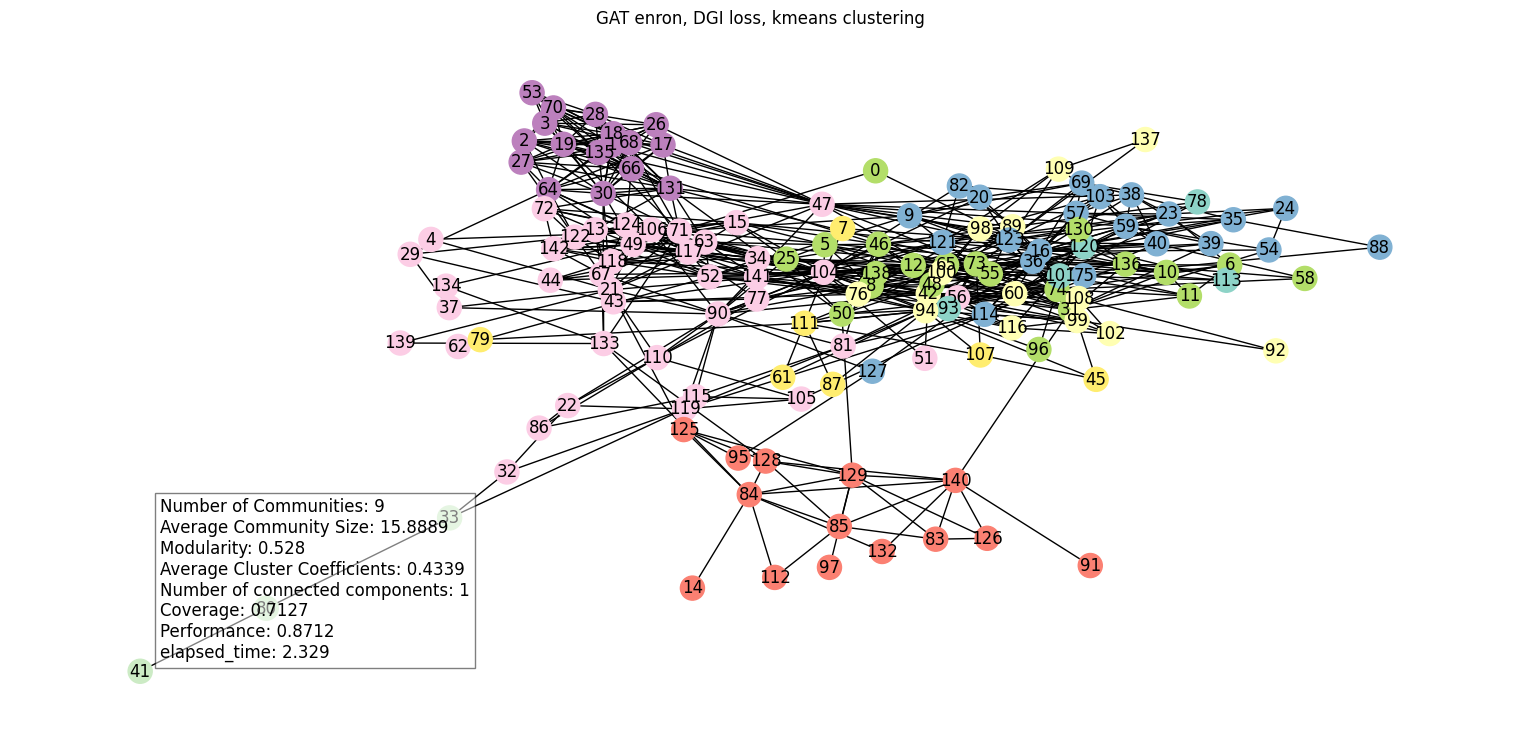

In [ ]:
# Print results for the best parameters and best clustering method
plot_communities(g, gat_dgi_communities, title=f"GAT {sel_graph}, DGI loss, {best_method} clustering", metrics=best_results['GAT + DGI loss'])

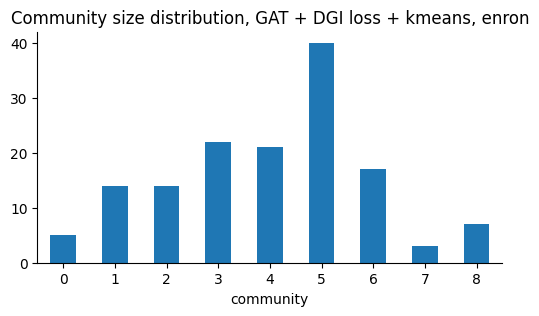

In [ ]:
community_size_hist(gat_dgi_communities, title=f"Community size distribution, GAT + DGI loss + {best_method}, {sel_graph}")

## Embedding variance loss

### Hyperparameter selection

In [ ]:
best_parameters_optuna_var = tune_variance_contrastive(data, g, loss_function="variance")

/home/jann/GAT/venv/lib/python3.10/site-packages/sklearn/cluster/_optics.py:1083: RuntimeWarning: divide by zero encountered in divide
  ratio = reachability_plot[:-1] / reachability_plot[1:]


In [ ]:
gat_var_communities = best_parameters_optuna_var.best_trial.user_attrs['communities']
best_method = best_parameters_optuna_var.best_trial.user_attrs['best_method']
best_results['GAT + variance loss'] = best_parameters_optuna_var.best_trial.user_attrs['metrics']
best_results['GAT + variance loss']['elapsed_time'] = best_parameters_optuna_var.best_trial.user_attrs['elapsed_time']

### Model evaluation

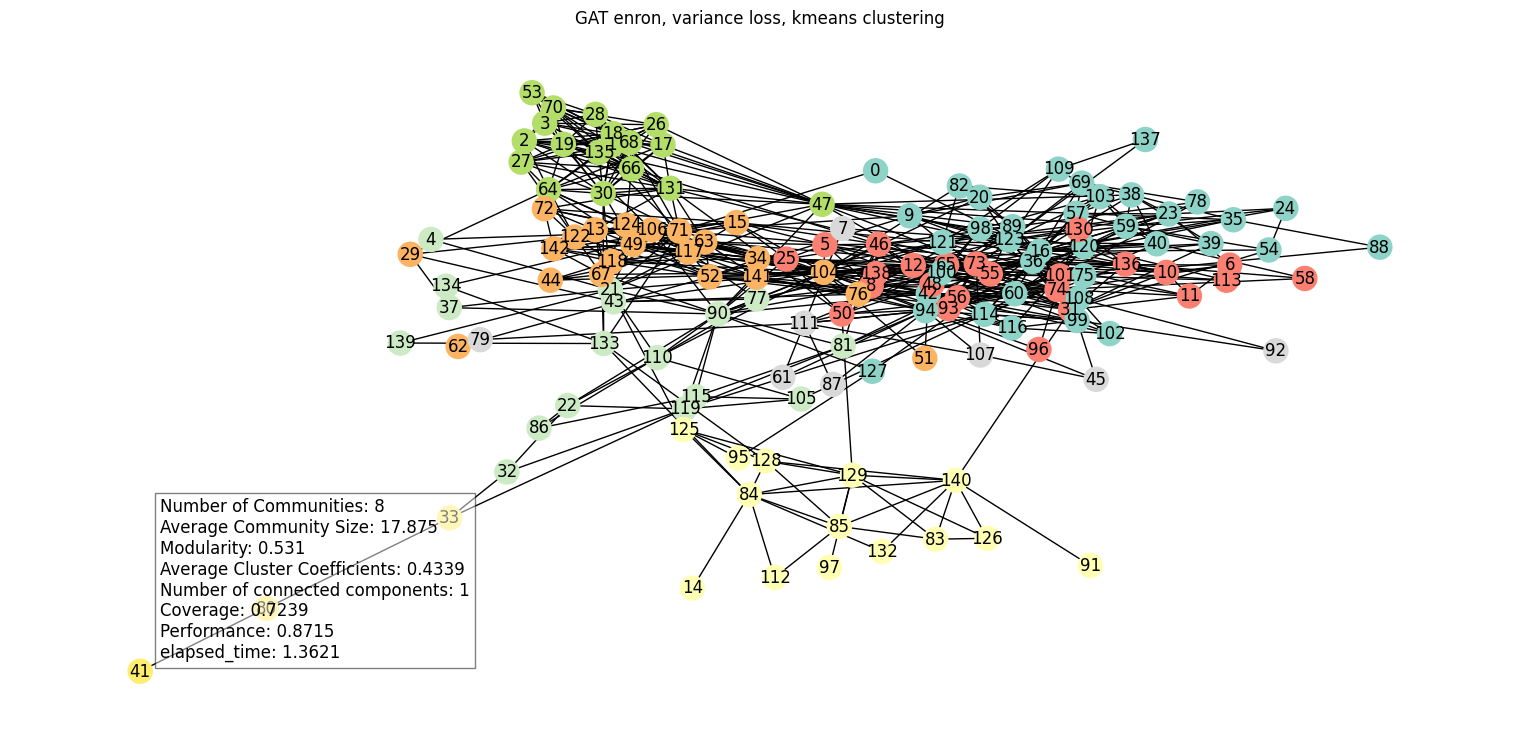

In [ ]:
# get visualizations and metrics
plot_communities(g, gat_var_communities, title=f"GAT {sel_graph}, variance loss, {best_method} clustering", metrics=best_results['GAT + variance loss'])

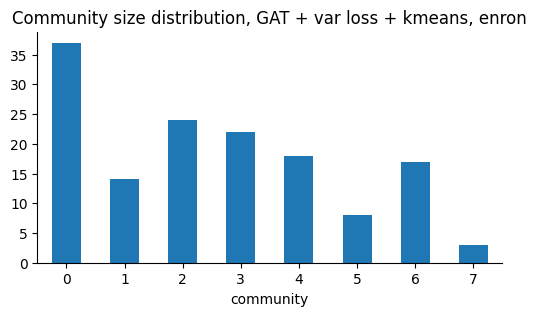

In [ ]:
community_size_hist(gat_var_communities, title=f"Community size distribution, GAT + var loss + {best_method}, {sel_graph}")

## Contrastive loss

### Hyperparameter selection

In [ ]:
best_parameters_optuna_con = tune_variance_contrastive(data, g, loss_function="contrastive")

### Model evaluation

In [ ]:
gat_con_communities = best_parameters_optuna_con.best_trial.user_attrs['communities']
best_method = best_parameters_optuna_con.best_trial.user_attrs['best_method']
best_results['GAT + contrastive loss'] = best_parameters_optuna_con.best_trial.user_attrs['metrics']
best_results['GAT + contrastive loss']['elapsed_time'] = best_parameters_optuna_con.best_trial.user_attrs['elapsed_time']

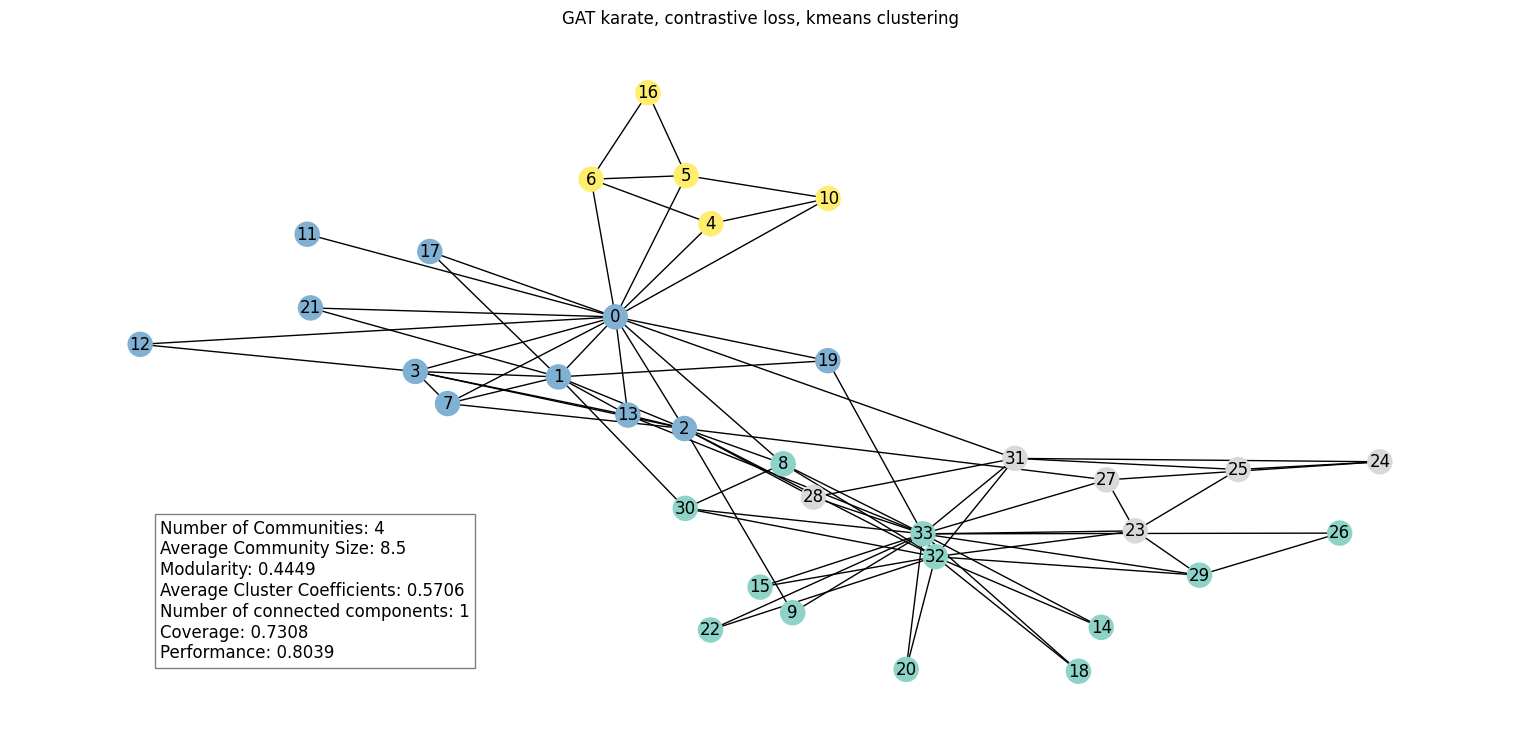

In [ ]:
plot_communities(g, gat_con_communities, title=f"GAT {sel_graph}, contrastive loss, {best_method} clustering", metrics=best_results['GAT + contrastive loss'])

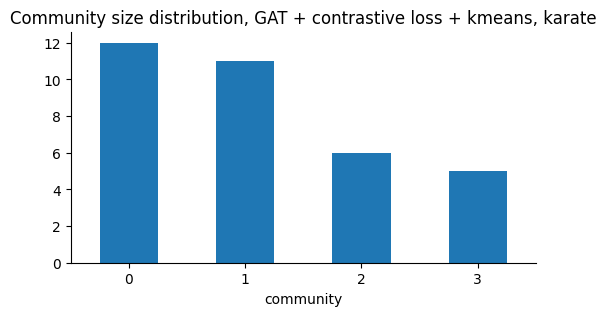

In [ ]:
community_size_hist(gat_con_communities, title=f"Community size distribution, GAT + contrastive loss + {best_method}, {sel_graph}")

# Final result

## Metrics

In [ ]:
final_metrics = pd.DataFrame(best_results).T.drop(["Average Cluster Coefficients", "Number of connected components"], axis=1)
final_metrics.style.format(precision=3).background_gradient(cmap='Blues', axis=None)

,Average Community Size,Coverage,Iterations,Modularity,Number of Communities,Performance,Resolution,elapsed_time
Label Propagation,11.333,0.769,1.000,0.309,3.000,0.668,nan,0.002
Louvaine,8.500,0.731,nan,0.445,4.000,0.804,1.000,0.004
Leiden,8.500,0.731,nan,0.445,4.000,0.804,nan,0.004
GAT + DGI loss,8.500,0.731,nan,0.420,4.000,0.804,nan,1.066
GAT + variance loss,8.500,0.731,nan,0.445,4.000,0.804,nan,0.659
GAT + contrastive loss,8.500,0.731,nan,0.445,4.000,0.804,nan,4.245


## Execution times (CPU)

In [ ]:
pd.DataFrame(final_metrics['elapsed_time']).T.style.format(precision=4).background_gradient(cmap='Blues', axis=None)

,Label Propagation,Louvaine,Leiden,GAT + DGI loss,GAT + variance loss,GAT + contrastive loss
elapsed_time,0.0019,0.0042,0.0045,1.0662,0.6593,4.2447


## Optuna best hyperparameters for GAT

In [ ]:
hyperparameters = pd.DataFrame({
    "GAT + DGI loss": best_parameters_optuna_dgi.best_params,
    "GAT + variance loss": best_parameters_optuna_var.best_params,
    "GAT + contrastive loss": best_parameters_optuna_con.best_params}).T
int_cols = ['hidden_channels', 'out_channels', 'heads']
hyperparameters[int_cols] = hyperparameters[int_cols].astype(int)
hyperparameters.style.format(precision=6).background_gradient(cmap='Blues', axis=None)

,hidden_channels,out_channels,heads,learning_rate,dropout,weight_decay
GAT + DGI loss,13,15,15,0.000224,0.149454,0.000028
GAT + variance loss,30,10,6,0.000752,0.117798,0.000128
GAT + contrastive loss,60,16,15,0.004454,0.319666,0.000881
